In [ ]:
!pip install gurobipy
!pip install shapely
!pip install haversine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.4/14.4 MB 54.7 MB/s eta 0:00:00


In [ ]:
import numpy as np
from scipy.spatial import distance_matrix
from gurobipy import *
from scipy.spatial import ConvexHull
from shapely.geometry import Polygon, Point
from numpy import random
import time
import pandas as pd
from itertools import zip_longest
from haversine import haversine

1. 데이터 저장

In [ ]:
입지후보지 = pd.read_excel('청소년공모전서울시_행정기관_행정동추가.xlsx')
입지후보지 = 입지후보지[입지후보지['행정동'].isin(['구산동'])]
# 위도와 경도가 모두 같은 데이터에서 첫 번째 데이터만 남기기, 같은 위치의 중고등학교가 있기 때문
입지후보지 = 입지후보지.drop_duplicates(subset=['위도', '경도'], keep='first')
print(입지후보지.shape)
입지후보지.head(2)

(1, 13)


,기관유형,기관유형별분류,대표기관명,전체기관명,최하위기관명,대표전화번호,새우편번호,도로명주소,위도,경도,행정동,행정동_경도,행정동_위도
816,지자체,8읍면동_동,서울특별시,서울특별시 은평구 구산동주민센터,구산동주민센터,02-351-5152,3426,서울특별시 은평구 갈현로17길 10 (구산동),37.609839,126.913504,구산동,126.910376,37.611757


In [ ]:
학교 = pd.read_excel('청소년공모전서울시_학교_행정동추가.xlsx')
학교 = 학교[학교['행정동'].isin(['구산동'])]
학교 = 학교.drop_duplicates(subset=['위도', '경도'], keep='first')
print(학교.shape)
학교.head(2)
#학교 = 학교[학교['행정동'].isin(['구로1동', '구로2동', '구로3동', '구로4동', '구로5동','신도림동','가리봉동','고척제1동','고척제2동','개봉제1동','개봉제2동','개봉제3동','오류제1동','오류제2동','항동','수궁동'])]

(6, 24)


,index,학교ID,학교명,학교급구분,설립일자,설립형태,본교분교구분,운영상태,소재지지번주소,소재지도로명주소,...,생성일자,변경일자,위도,경도,데이터기준일자,제공기관코드,제공기관명,행정동,행정동_경도,행정동_위도
31,245,B000001888,서울구산초등학교,초등학교,1977.11.29,공립,본교,운영,서울특별시 은평구 구산동 152-3,서울특별시 은평구 서오릉로15길 16,...,2013.11.29,2024.7.9,37.612751,126.909376,2024.9.20,B555223,재단법인한국지방교육행정연구재단,구산동,126.910376,37.611757
95,921,B000011326,예일디자인고등학교,고등학교,1993.9.26,사립,본교,운영,서울특별시 은평구 구산동 8-3,서울특별시 은평구 연서로 117,...,2013.11.29,2024.7.9,37.610946,126.914793,2024.9.20,B555223,재단법인한국지방교육행정연구재단,구산동,126.910376,37.611757


In [ ]:
버스 = pd.read_excel('청소년공모전서울시_버스정류장_행정동추가.xlsx')
버스 = 버스[버스['행정동'].isin(['구산동'])]
버스 = 버스.drop_duplicates(subset=['X좌표', 'Y좌표'], keep='first')
print(버스.shape)
버스.head(2)

(32, 9)


,NODE_ID,ARS_ID,정류소명,X좌표,Y좌표,정류소타입,행정동,행정동_경도,행정동_위도
4383,111000058,12146,서울경찰청86.87기동대.우남아파트,126.905831,37.618528,일반차로,구산동,126.910376,37.611757
4384,111000059,12147,선정중고등학교,126.908080,37.615716,일반차로,구산동,126.910376,37.611757


In [ ]:
지하철 = pd.read_excel('청소년공모전서울시_지하철역_행정동추가.xlsx')
지하철 = 지하철[지하철['행정동'].isin(['구산동'])]
지하철 = 지하철.drop_duplicates(subset=['X좌표', 'Y좌표'], keep='first')
print(지하철.shape)
지하철.head(2)

(0, 6)


,역,Y좌표,X좌표,행정동,행정동_경도,행정동_위도


2. 수요지점 좌표 리스트 생성

In [ ]:
# Haversine 패키지에 이용하기 위해 Y 좌표, X좌표 순
버스_points = np.array([list(i) for i in zip(버스['Y좌표'], 버스['X좌표'])])
print(버스_points.shape)
버스_points[:2]

(32, 2)


array([[ 37.61852843, 126.90583082],
       [ 37.61571646, 126.90808009]])

In [ ]:
# Haversine 패키지에 이용하기 위해 Y좌표, X좌표 순
지하철_points = np.array([list(i) for i in zip(지하철['Y좌표'], 지하철['X좌표'])])
print(지하철_points.shape)
지하철_points[:2]

(0,)


array([], dtype=float64)

In [ ]:
학교_points = np.array([list(i) for i in zip(학교['위도'], 학교['경도'])])
print(학교_points.shape)
학교_points[:2]

(6, 2)


array([[ 37.61275096, 126.9093765 ],
       [ 37.6109459 , 126.9147928 ]])

In [ ]:
# 시각화 표기용 X좌표, Y좌표 순
X = list(버스['X좌표']) + list(지하철['X좌표'])+list(학교['경도'])
X[:2]

[126.9058308185, 126.9080800916]

In [ ]:
# 시각화 표기용 X좌표, Y좌표 순
Y = list(버스['Y좌표']) + list(지하철['Y좌표'])+list(학교['위도'])
Y[:2]

[37.6185284274, 37.6157164599]

In [ ]:
# 시각화 표기용 X좌표, Y좌표 순
points = np.array([list(i) for i in zip(X, Y)])
print(points.shape)
points[:2]

(38, 2)


array([[126.90583082,  37.61852843],
       [126.90808009,  37.61571646]])

In [ ]:
수요지점 = pd.DataFrame(points, columns=['경도','위도'])
수요지점.head(2)

,경도,위도
0,126.905831,37.618528
1,126.908080,37.615716


3. MCLP 구현

Haversine 패키지에서는 Y좌표, X좌표 순으로 계산해줘야함.

In [ ]:
def mclp(버스_points, 지하철_points, 학교_points, points, K, radius):
    """
    Solve maximum covering location problem
    Input:
        points: 수요지점 좌표 (기타 인근에 있으면 좋은 시설 좌표)
        K: 배치할 입지 후보지(독서실) 개수
        radius: 반경 (학생들이 이동하기 적합한 거리)
    Return:
        opt_sites: locations K optimal sites, Numpy array in shape of [K,2]
        f: the optimal value of the objective function
    """
    print('  Number of points %g' % points.shape[0])
    print('  K %g' % K)
    print('  Radius %g' % radius)

    start = time.time()
    sites = np.array([list(i) for i in zip(입지후보지['위도'], 입지후보지['경도'])]) #haversine용이기 때문에 거꾸로 넣음
    J = sites.shape[0]

    # 수요지점 수
    A = 버스_points.shape[0]
    B = 지하철_points.shape[0]
    C = 학교_points.shape[0]

    # 입지후보지와 수요지점 간 거리 계산 (haversine으로 수정)
    D1 = []
    for i in 버스_points:
        site = []
        for j in sites:
            site.append(haversine(i, j)*1000)     # 단위를 m로 변경하기 위해 *1000
        D1.append(site)
    D1 = np.array(D1)

    D2 = []
    for i in 지하철_points:
        site = []
        for j in sites:
            site.append(haversine(i, j)*1000)
        D2.append(site)
    D2 = np.array(D2)

    D3 = []
    for i in 학교_points:
        site = []
        for j in sites:
            site.append(haversine(i, j)*1000)
        D3.append(site)
    D3 = np.array(D3)


    for i in [D1, D2, D3]:
        mask1 = i<=radius
        i[mask1]=1
        i[~mask1]=0

    m = Model()
    x1, x2, x3 = {}, {}, {}
    y = {}

    # 수요지점 변수 추가
    for i in range(A):
        x1[i] = m.addVar(vtype=GRB.BINARY, name="x1%d" % i)
    for i in range(B):
        x2[i] = m.addVar(vtype=GRB.BINARY, name="x2%d" % i)
    for i in range(C):
        x3[i] = m.addVar(vtype=GRB.BINARY, name="x3%d" % i)

    # 입지후보지 변수 추가
    for j in range(J):
        y[j] = m.addVar(vtype=GRB.BINARY, name="y%d" % j)

    m.update()
    m.addConstr(quicksum(y[j] for j in range(J)) == K)

    # 수요지점 제약 조건
    for i in range(A):
        m.addConstr(quicksum(y[j] for j in np.where(D1[i]==1)[0]) >= x1[i])
    for i in range(B):
        m.addConstr(quicksum(y[j] for j in np.where(D2[i]==1)[0]) >= x2[i])
    for i in range(C):
        m.addConstr(quicksum(y[j] for j in np.where(D3[i]==1)[0]) >= x3[i])

    # 목적함수 수정
    m.setObjective(quicksum(i for i in [1*x1[a] for a in range(A)] + [1*x2[b] for b in range(B)]+ [1*x3[c] for c in range(C)]),\
                   GRB.MAXIMIZE)     # 1 대신 가중치 입력

    m.setParam('OutputFlag', 0)
    m.optimize()
    end = time.time()
    print('----- Output -----')
    print('  Running time : %s seconds' % float(end-start))
    print('  Optimal coverage points: %g' % m.objVal)

    solution = []
    if m.status == GRB.Status.OPTIMAL:
        for v in m.getVars():
            if v.x==1 and v.varName[0]=="y":
                solution.append(int(v.varName[1:]))
    opt_sites = sites[solution]
    return opt_sites,m.objVal

In [ ]:
opts_sites, mobjVal = mclp(버스_points, 지하철_points, 학교_points, points, 3, 200)
opts_sites = opts_sites[:, [1, 0]] # haversine 패키지에서 계산하기 위해 바꿨기 때문에 지도에 표기하기 위해 다시 바꿈
opts_sites

  Number of points 38
  K 3
  Radius 200
----- Output -----
  Running time : 0.002958536148071289 seconds


AttributeError: Unable to retrieve attribute 'objVal'

In [ ]:
최적입지 = pd.DataFrame(opts_sites, columns=['경도','위도'])
최적입지

,경도,위도
0,126.887654,37.495291
1,126.890329,37.487420
2,126.898493,37.484219


In [ ]:
def plot_input(points):
    '''
    Plot the result
    Input:
        points: input points, Numpy array in shape of [N,2]
        opt_sites: locations K optimal sites, Numpy array in shape of [K,2]
        radius: the radius of circle
    '''
    from matplotlib import pyplot as plt
    fig = plt.figure(figsize=(8,8))
    plt.scatter(points[:,0],points[:,1],c='C0')
    ax = plt.gca()
    ax.axis('equal')
    ax.tick_params(axis='both',left=False, top=False, right=False,
                       bottom=False, labelleft=False, labeltop=False,
                       labelright=False, labelbottom=False)

In [ ]:
def plot_result(points,opt_sites,radius):
    '''
    Plot the result
    Input:
        points: input points, Numpy array in shape of [N,2]
        opt_sites: locations K optimal sites, Numpy array in shape of [K,2]
        radius: the radius of circle
    '''
    from matplotlib import pyplot as plt
    fig = plt.figure(figsize=(8,8))
    plt.scatter(points[:,0],points[:,1],c='C0')
    ax = plt.gca()
    plt.scatter(opt_sites[:,0],opt_sites[:,1],c='C1',marker='+')
    for site in opt_sites:
        circle = plt.Circle(site, radius, color='C1',fill=False,lw=2)
        ax.add_artist(circle)
    ax.axis('equal')
    ax.tick_params(axis='both',left=False, top=False, right=False,
                       bottom=False, labelleft=False, labeltop=False,
                       labelright=False, labelbottom=False)

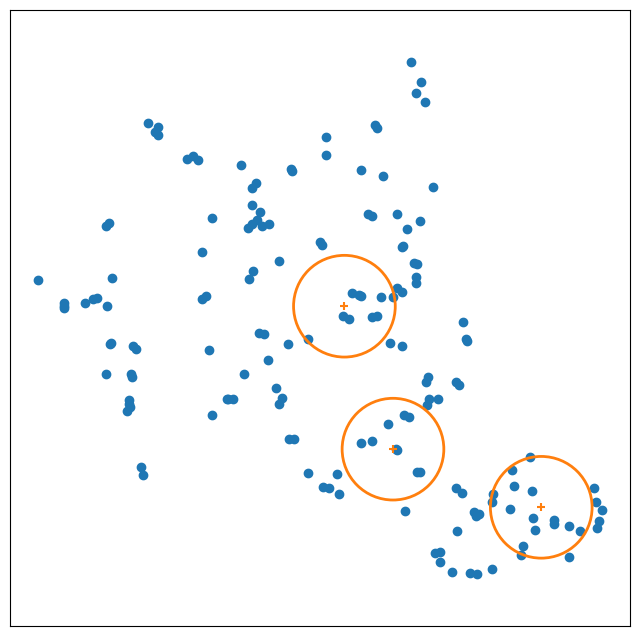

In [ ]:
plot_result(points, opts_sites, 0.0028)

In [ ]:
result = 입지후보지[
    입지후보지[['경도', '위도']].apply(tuple, axis=1).isin(
        최적입지[['경도', '위도']].apply(tuple, axis=1)
    )
]['전체기관명']

print(result)

444                서울특별시 구로구청
575        서울특별시 구로구 구로3동주민센터
1037    서울특별시 구로소방서 공단119안전센터
Name: 전체기관명, dtype: object


In [ ]:
# 제대로 시각화 되지 않았을 경우 수요지점 확인용 코드
print(f"points shape: {points.shape}")
print(f"points data: {points[:10]}")  # 샘플 데이터 확인

points shape: (162, 2)
points data: [[126.87469975  37.49988063]
 [126.87453607  37.49970251]
 [126.90154813  37.48309943]
 [126.8921031   37.50654722]
 [126.89157079  37.50701588]
 [126.889452    37.505102  ]
 [126.88931907  37.50525394]
 [126.88978206  37.50247704]
 [126.88854889  37.50277998]
 [126.89183549  37.49997415]]
